In [1]:
# Cell 1: 데이터 초기화 및 GPU 확인
import torch
import gc
import random
import numpy as np

# GPU 메모리 정리
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print("GPU 메모리 정리 완료")

# Python 가비지 컬렉션
gc.collect()

# 재현성을 위한 시드 설정
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"랜덤 시드 설정 완료: {RANDOM_SEED}")

# GPU 확인
print('GPU not found.') if not torch.cuda.is_available() else print(f'Found GPU: {torch.cuda.get_device_name(0)}')

GPU 메모리 정리 완료
랜덤 시드 설정 완료: 42
Found GPU: NVIDIA GeForce RTX 3070


In [2]:
# Cell 2: 라이브러리 import
import torch
import numpy as np
from pathlib import Path
from utils.patch_cnn.classifier import initialize_defect_classifier, load_defect_classifier
from utils.patch_cnn.dataset_functions import (
    create_defect_only_patch_dataset, get_label_mapping,
    get_albumentations_transform
)
from utils.patch_cnn.federated_averaging import federated_averaging_defect_classifier
from utils.patch_cnn.visualization import plot_training_curves

In [3]:
# Cell 3: 레이블 매핑 생성 (먼저 수행)

data_dir = 'data_test/'

# 임시로 모든 파일을 사용하여 레이블 매핑 생성
temp_client_dict = {'temp': [f'{i:06d}' for i in range(1, 79)]}
all_label_mapping, all_num_classes = get_label_mapping(data_dir, temp_client_dict)

# 결함 유형만 포함하는 레이블 매핑 생성 (0, 1, -1 제외)
defect_only_label_mapping = {}
defect_classes = []
for original_label, mapped_label in all_label_mapping.items():
    # 0, 1, -1은 정상 부분이므로 제외
    if original_label not in [0, 1, -1]:
        defect_only_label_mapping[original_label] = len(defect_classes)
        defect_classes.append(original_label)

num_defect_classes = len(defect_classes)
print(f"\n결함 유형 클래스 수: {num_defect_classes}")
print(f"결함 유형 매핑: {defect_only_label_mapping}")
print(f"결함 유형 원본 값: {defect_classes}")

발견된 모든 레이블 유형: [np.int32(-1), np.int8(0), np.int8(1), np.int32(2), np.int8(3), np.int8(4), np.int8(5), np.int32(6), np.int8(7), np.int8(8), np.int8(9), np.int8(11), np.int8(14)]
레이블 매핑: {np.int32(-1): 0, np.int8(0): 1, np.int8(1): 2, np.int32(2): 3, np.int8(3): 4, np.int8(4): 5, np.int8(5): 6, np.int32(6): 7, np.int8(7): 8, np.int8(8): 9, np.int8(9): 10, np.int8(11): 11, np.int8(14): 12}
총 클래스 수: 13

결함 유형 클래스 수: 10
결함 유형 매핑: {np.int32(2): 0, np.int8(3): 1, np.int8(4): 2, np.int8(5): 3, np.int32(6): 4, np.int8(7): 5, np.int8(8): 6, np.int8(9): 7, np.int8(11): 8, np.int8(14): 9}
결함 유형 원본 값: [np.int32(2), np.int8(3), np.int8(4), np.int8(5), np.int32(6), np.int8(7), np.int8(8), np.int8(9), np.int8(11), np.int8(14)]


In [4]:
# Cell 4: 전체 데이터에서 패치 생성 및 증강
from utils.patch_cnn.dataset_functions import (
    create_all_patches_with_augmentation,
    distribute_patches_non_iid_by_defect_type,
    get_albumentations_transform
)


all_files = [f'{i:06d}' for i in range(1, 79)]

PATCH_SIZE = (256, 256)
PATCH_OVERLAP = 0
MIN_DEFECT_RATIO = 0.1
MIN_CONFIDENCE = 0.3

# Albumentations 증강 설정
train_transform = get_albumentations_transform(is_training=True)
val_transform = get_albumentations_transform(is_training=False)

print("=" * 60)
print("Step 1: 전체 데이터에서 패치 생성 및 증강")
print("=" * 60)
all_patches, all_labels, all_metadata, defect_type_ratios = create_all_patches_with_augmentation(
    all_files=all_files,
    data_dir=data_dir,
    patch_size=PATCH_SIZE,
    patch_overlap=PATCH_OVERLAP,
    min_defect_ratio=MIN_DEFECT_RATIO,
    min_confidence=MIN_CONFIDENCE,
    label_mapping=defect_only_label_mapping,
    transform=train_transform
)

print("\n" + "=" * 60)
print("Step 2: 증강된 패치를 Non-IID로 클라이언트에 분배")
print("=" * 60)
num_clients = 6
bias_strength = 0.8

trainImageDict, trainLabelDict, trainMetadataDict = distribute_patches_non_iid_by_defect_type(
    all_patches=all_patches,
    all_labels=all_labels,
    all_metadata=all_metadata,
    num_clients=num_clients,
    bias_strength=bias_strength
)

print("\n※ 분산 평가 방식: 테스트 데이터셋은 각 클라이언트 내에서 분할됩니다.")

Step 1: 전체 데이터에서 패치 생성 및 증강
전체 파일에서 패치 생성 중...
  처리 중: 20/78 파일 완료 (패치: 286개)
  처리 중: 40/78 파일 완료 (패치: 583개)
  처리 중: 60/78 파일 완료 (패치: 769개)
총 1248개 패치 중 296개 제외됨, 952개 사용

패치 생성 후 결함 유형별 패치 개수 비율 계산 중...
결함 유형별 패치 비율: {6: 0.22899159663865545, 3: 0.1092436974789916, 2: 0.27521008403361347, 4: 0.10294117647058823, 0: 0.15231092436974789, 8: 0.059873949579831935, 5: 0.01365546218487395, 7: 0.015756302521008403, 1: 0.04201680672268908}

결함 유형별 패치 개수:
  결함 0: 145개 (15.23%)
  결함 1: 40개 (4.20%)
  결함 2: 262개 (27.52%)
  결함 3: 104개 (10.92%)
  결함 4: 98개 (10.29%)
  결함 5: 13개 (1.37%)
  결함 6: 218개 (22.90%)
  결함 7: 15개 (1.58%)
  결함 8: 57개 (5.99%)

증강 적용 중...

원본 패치: 952개
증강 적용 후: 3944개

증강 전후 결함 유형별 비교
결함 유형        증강 전                 증강 후                 증강 배수        비율 변화          
------------------------------------------------------------------------------------------
결함 3           104개 (10.92%)     624개 (15.82%)       6.00x        +4.90%
결함 4            98개 (10.29%)     588개 (14.91%)       6.

In [5]:
# Cell 5: 분산 평가 방식 Train/Val/Test로 분할

# num_clients는 Cell 3에서 이미 정의됨 (또는 여기서 다시 정의)
if 'num_clients' not in locals():
    num_clients = 6

trainClients = [f'client{i}' for i in range(1, num_clients + 1)]  # 모든 클라이언트 포함

print(f"학습 클라이언트: {trainClients}")
print(f"총 클라이언트 수: {len(trainClients)}")
print("\n※ 분산 평가 방식:")
print("  - 각 클라이언트가 자신의 데이터를 Train(60%)/Val(20%)/Test(20%)로 분할")
print("  - 각 클라이언트가 자신의 테스트 데이터로 평가")
print("  - 서버가 클라이언트별 정확도의 가중 평균 계산")

학습 클라이언트: ['client1', 'client2', 'client3', 'client4', 'client5', 'client6']
총 클라이언트 수: 6

※ 분산 평가 방식:
  - 각 클라이언트가 자신의 데이터를 Train(60%)/Val(20%)/Test(20%)로 분할
  - 각 클라이언트가 자신의 테스트 데이터로 평가
  - 서버가 클라이언트별 정확도의 가중 평균 계산


In [10]:
# Cell 6: 하이퍼파라미터 설정
SERVER_ROUNDS = 20
LOCAL_EPOCHS = 10
LOCAL_BATCH_SIZE = 32
LOCAL_LEARNING_RATE = 1e-4
EARLY_STOPPING_ACCURACY = 95.0
FREEZE_EPOCHS = 3  # 초기 몇 에포크는 backbone 고정
K_FOLDS = 5  # K-Fold 교차 검증

In [11]:
# Cell 7: 모델 초기화
import os
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 저장된 모델 경로 설정
saved_model_dir = Path('saved_models')
model_filename = 'none'  # 원하는 모델 파일명으로 변경 가능
model_path = saved_model_dir / model_filename

# 저장된 모델이 있으면 로드, 없으면 새로 초기화
if model_path.exists():
    print(f"저장된 모델 발견: {model_path}")
    print("모델 로드 중...")
    model = load_defect_classifier(
        model_path=str(model_path),
        num_classes=num_defect_classes,
        device=device
    )
    print(f"저장된 모델 로드 완료! 클래스 수: {num_defect_classes}")
else:
    print("저장된 모델이 없습니다. 새 모델을 초기화합니다.")
    # ResNet-18 기반 결함 유형 분류 모델 초기화
    # ImageNet 사전 학습, 초기에는 backbone 고정
    model = initialize_defect_classifier(
        num_classes=num_defect_classes,
        input_channels=2,
        device=device,
        pretrained=True,
        freeze_backbone=True  # 초기에는 고정
    )
    print(f"결함 유형 분류 모델 초기화 완료! 클래스 수: {num_defect_classes}")

print(f"Device: {device}")

저장된 모델이 없습니다. 새 모델을 초기화합니다.
결함 유형 분류 모델 초기화 완료! 클래스 수: 10
Device: cuda


In [12]:
# Cell 8: 연합학습 실행 (결함 유형 분류 모델) - 분산 평가 방식
model, serverStateDict, lossDict, testLoss, accuracyDict, testAccuracy = federated_averaging_defect_classifier(
    model,
    SERVER_ROUNDS, LOCAL_EPOCHS, LOCAL_BATCH_SIZE, LOCAL_LEARNING_RATE,
    trainClients, trainImageDict, trainLabelDict,  # testImages, testLabels 제거
    num_defect_classes,
    device=device,
    early_stopping_accuracy=EARLY_STOPPING_ACCURACY,
    freeze_epochs=FREEZE_EPOCHS,
    train_ratio=0.6,  # 60% 학습
    val_ratio=0.2,    # 20% 검증
    test_ratio=0.2    # 20% 테스트
)


클라이언트 데이터 개수 및 가중치 비율:
  client1: 746개 샘플, 비율: 0.1891
  client2: 586개 샘플, 비율: 0.1486
  client3: 672개 샘플, 비율: 0.1704
  client4: 780개 샘플, 비율: 0.1978
  client5: 753개 샘플, 비율: 0.1909
  client6: 407개 샘플, 비율: 0.1032
------ Server Round 0 ------

Running local updates for client1...
Epoch 1/10 - Loss: 1.9002, Val Accuracy: 63.76%
Epoch 2/10 - Loss: 1.5139, Val Accuracy: 66.44%
Epoch 3/10 - Loss: 1.3291, Val Accuracy: 65.77%
Epoch 4/10 - Loss: 1.2747, Val Accuracy: 65.77%
Epoch 5/10 - Loss: 1.1935, Val Accuracy: 65.77%
Epoch 6/10 - Loss: 1.1622, Val Accuracy: 67.11%
Epoch 7/10 - Loss: 1.0974, Val Accuracy: 67.11%
Epoch 8/10 - Loss: 1.0658, Val Accuracy: 67.79%
Epoch 9/10 - Loss: 1.0233, Val Accuracy: 68.46%
Epoch 10/10 - Loss: 1.0133, Val Accuracy: 70.47%
Saving local updates for client1...

Running local updates for client2...
Epoch 1/10 - Loss: 1.9931, Val Accuracy: 65.81%
Epoch 2/10 - Loss: 1.6645, Val Accuracy: 64.10%
Epoch 3/10 - Loss: 1.4456, Val Accuracy: 60.68%
Epoch 4/10 - Loss: 1.336

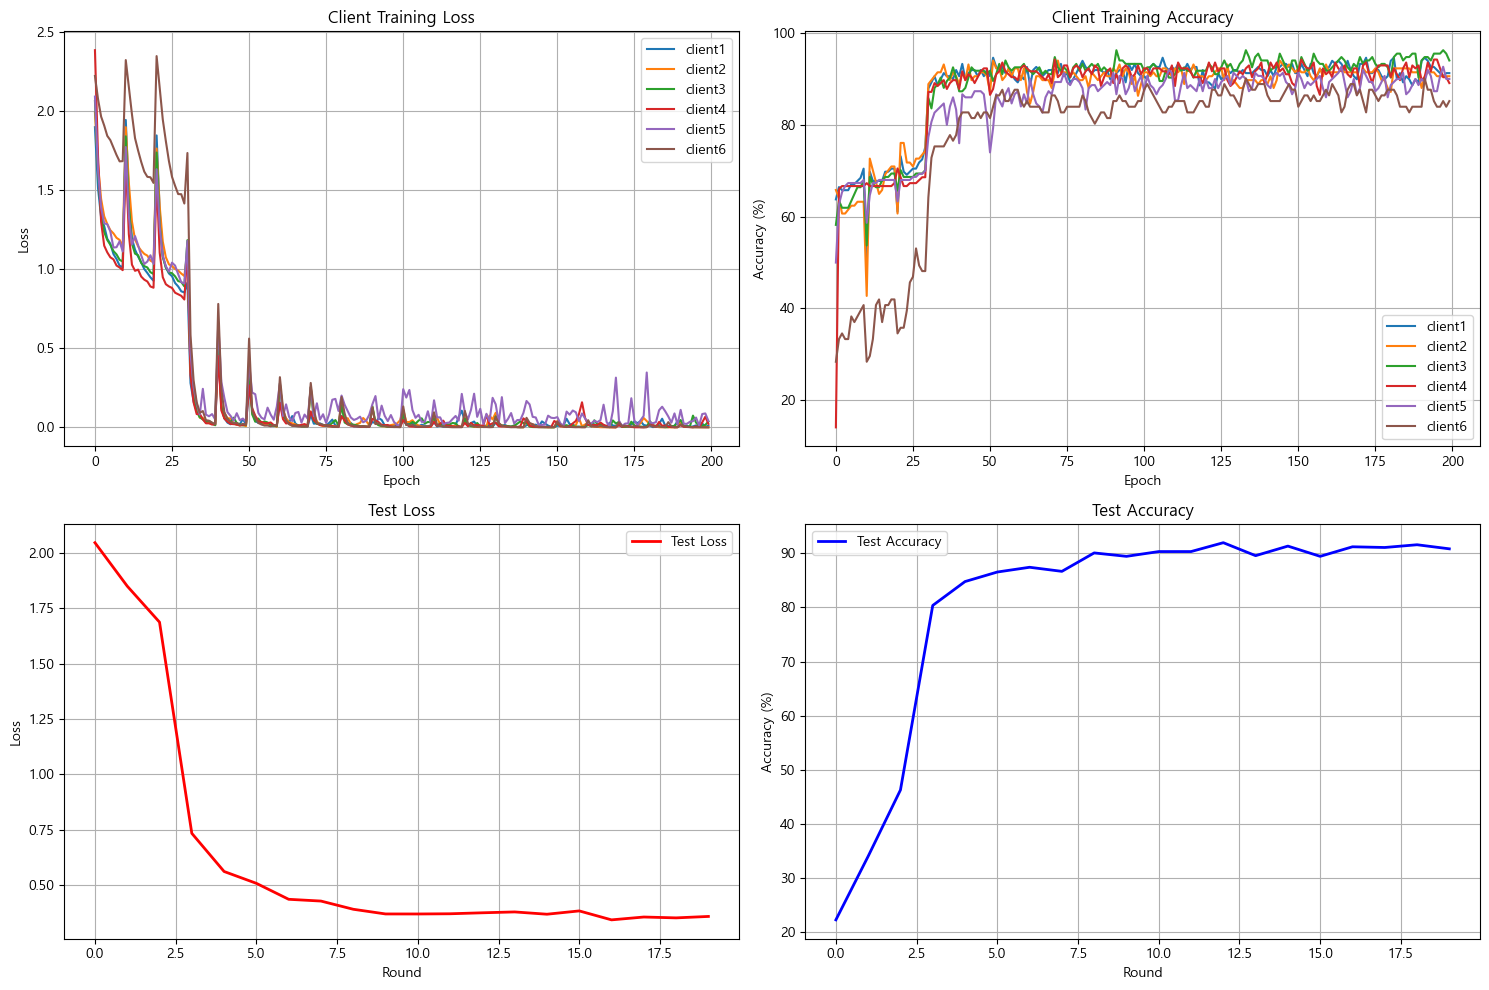

In [13]:
# Cell 9: 학습 곡선 시각화
plot_training_curves(lossDict, accuracyDict, testLoss, testAccuracy, trainClients)

In [14]:
# Cell 10: 모델 저장
import os
from pathlib import Path
from utils.patch_cnn.classifier import save_patch_cnn_model

os.makedirs('saved_models', exist_ok=True)

lr_str = f"{LOCAL_LEARNING_RATE:.0e}".replace('-', '').replace('+', '').replace('.0', '')
base_filename = f'saved_models/Defect_Classifier_FL_{SERVER_ROUNDS}_{LOCAL_EPOCHS}_{LOCAL_BATCH_SIZE}_{lr_str}.pth'

model_filename = base_filename
counter = 1
while os.path.exists(model_filename):
    base_name, ext = os.path.splitext(base_filename)
    model_filename = f'{base_name}_{counter}{ext}'
    counter += 1

save_patch_cnn_model(model, model_filename, num_classes=num_defect_classes)
print(f'\n최종 테스트 성능:')
print(f'  Loss: {testLoss[-1]:.4f}')
print(f'  Accuracy: {testAccuracy[-1]:.2f}%')
print(f'\n모델 저장 완료: {model_filename}')

# total_files 계산 (all_files가 정의되어 있으면 사용)
if 'all_files' in locals():
    total_files = len(all_files)
else:
    total_files = 78  # 기본값
print(f'사용된 데이터: {data_dir} ({total_files}개 파일)')

모델이 saved_models/Defect_Classifier_FL_20_10_32_1e04.pth에 저장되었습니다.

최종 테스트 성능:
  Loss: 0.3571
  Accuracy: 90.80%

모델 저장 완료: saved_models/Defect_Classifier_FL_20_10_32_1e04.pth
사용된 데이터: data_test/ (78개 파일)


In [2]:
# Cell 11: 테스트 데이터 시각화
from utils.patch_cnn.visualization import visualize_test_results

# 설정 (원하는 값으로 변경 가능)
MODEL_PATH = 'saved_models/Defect_Classifier_FL_20_10_32_1e04.pth'  # None이면 자동으로 가장 최근 모델 찾기
DATA_DIR = 'data_test/'  # 데이터셋 경로
TOTAL_FILES = 78  # 총 파일 개수

# 시각화 실행
visualize_test_results(
    model_path=MODEL_PATH,
    data_dir=DATA_DIR,
    total_files=TOTAL_FILES,
    patch_overlap=0,
    output_dir='visualizations',
    subdivide_small_images=True  # 파라미터 이름 변경
)

모델 로드: saved_models\Defect_Classifier_FL_20_10_32_1e04.pth
결함 유형 클래스 수: 10
결함 유형 매핑: {np.int32(2): 0, np.int8(3): 1, np.int8(4): 2, np.int8(5): 3, np.int32(6): 4, np.int8(7): 5, np.int8(8): 6, np.int8(9): 7, np.int8(11): 8, np.int8(14): 9}
결함 유형 원본 값: [np.int32(2), np.int8(3), np.int8(4), np.int8(5), np.int32(6), np.int8(7), np.int8(8), np.int8(9), np.int8(11), np.int8(14)]

처리 중: 000001 (1/78)
  이미지 정확도: 100.00% (14개 결함 패치 중 14개 정확)
  저장 완료: visualizations\visualization_000001.png

처리 중: 000002 (2/78)
  이미지 정확도: 90.91% (11개 결함 패치 중 10개 정확)
  저장 완료: visualizations\visualization_000002.png

처리 중: 000003 (3/78)
  이미지 정확도: 93.33% (15개 결함 패치 중 14개 정확)
  저장 완료: visualizations\visualization_000003.png

처리 중: 000004 (4/78)
  이미지 정확도: 86.67% (15개 결함 패치 중 13개 정확)
  저장 완료: visualizations\visualization_000004.png

처리 중: 000005 (5/78)
  이미지 정확도: 81.25% (16개 결함 패치 중 13개 정확)
  저장 완료: visualizations\visualization_000005.png

처리 중: 000006 (6/78)
  이미지 정확도: 75.00% (16개 결함 패치 중 12개 정확)
  저장 완료: visualiz